# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [43]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [44]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

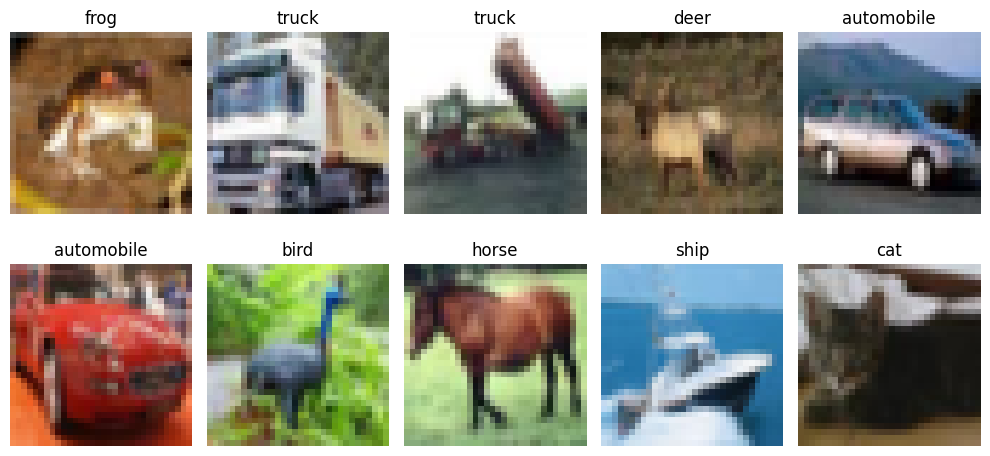

In [45]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [46]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [47]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.2680 - loss: 1.9959 - val_accuracy: 0.3330 - val_loss: 1.8319
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3189 - loss: 1.8638 - val_accuracy: 0.3650 - val_loss: 1.7713
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3380 - loss: 1.8193 - val_accuracy: 0.3768 - val_loss: 1.7818
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3529 - loss: 1.7817 - val_accuracy: 0.3754 - val_loss: 1.7339
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3616 - loss: 1.7540 - val_accuracy: 0.3922 - val_loss: 1.7119
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3646 - loss: 1.7402 - val_accuracy: 0.4134 - val_loss: 1.6744
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3727 - loss: 1.7313 - val_accuracy: 0.3964 - val_loss: 1.6934
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3814 - loss: 1.7059 - val_accuracy: 0.

In [48]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4177 - loss: 1.6429
ANN Test Accuracy: 0.41769999265670776


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [49]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4726 - loss: 1.4823 - val_accuracy: 0.4692 - val_loss: 1.5028
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6106 - loss: 1.1145 - val_accuracy: 0.6052 - val_loss: 1.1227
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6713 - loss: 0.9418 - val_accuracy: 0.6512 - val_loss: 1.0019
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7154 - loss: 0.8244 - val_accuracy: 0.7068 - val_loss: 0.8549
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7438 - loss: 0.7350 - val_accuracy: 0.6204 - val_loss: 1.2440
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7695 - loss: 0.6555 - val_accuracy: 0.7052 - val_loss: 0.9172
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7943 - loss: 0.5847 - val_accuracy: 0.7112 - val_loss: 0.8791
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8154 - loss: 0.5213 - val_accuracy: 

In [50]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7195 - loss: 0.9593
CNN Test Accuracy: 0.7195000052452087


## 📈 Compare Learning Curves

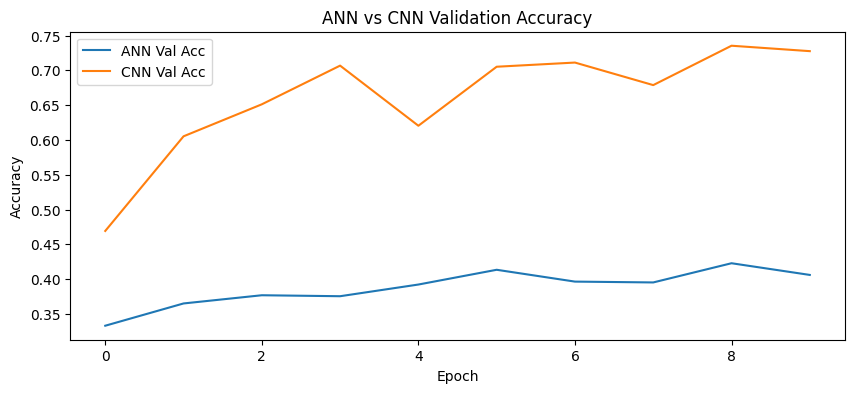

In [51]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [52]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [53]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4177
1,CNN,0.7195


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

Task 1 :Increase ANN layers and observe performance

In [54]:
ann_model_v2 = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history_v2 = ann_model_v2.fit(
    x_train_flat,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.2335 - loss: 2.0489 - val_accuracy: 0.3284 - val_loss: 1.8773
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2932 - loss: 1.9177 - val_accuracy: 0.3226 - val_loss: 1.8649
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3133 - loss: 1.8713 - val_accuracy: 0.3448 - val_loss: 1.8144
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3268 - loss: 1.8375 - val_accuracy: 0.3692 - val_loss: 1.7862
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3380 - loss: 1.8172 - val_accuracy: 0.3500 - val_loss: 1.7717
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3472 - loss: 1.7894 - val_accuracy: 0.3802 - val_loss: 1.7936
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3558 - loss: 1.7726 - val_accuracy: 0.4064 - val_loss: 1.7103
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3614 - loss: 1.7544 - val_accuracy: 

In [55]:
ann_v2_loss, ann_v2_acc = ann_model_v2.evaluate(x_test_flat, y_test)

print("Improved ANN Test Accuracy:", ann_v2_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4064 - loss: 1.6642
Improved ANN Test Accuracy: 0.40639999508857727


In [56]:
print(f"Original ANN Accuracy : {ann_test_acc:.4f}")
print(f"Improved ANN Accuracy : {ann_v2_acc:.4f}")

Original ANN Accuracy : 0.4177
Improved ANN Accuracy : 0.4064


Task 2 : Change CNN filters from 32→64→128

In [57]:
cnn_model_v2 = models.Sequential([

    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
cnn_history_v2 = cnn_model_v2.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.4914 - loss: 1.4294 - val_accuracy: 0.5942 - val_loss: 1.1490
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6438 - loss: 1.0243 - val_accuracy: 0.5494 - val_loss: 1.3914
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7027 - loss: 0.8544 - val_accuracy: 0.6152 - val_loss: 1.1042
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7489 - loss: 0.7227 - val_accuracy: 0.6912 - val_loss: 0.9117
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7875 - loss: 0.6065 - val_accuracy: 0.5982 - val_loss: 1.3100
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8144 - loss: 0.5242 - val_accuracy: 0.6918 - val_loss: 1.0045
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8439 - loss: 0.4442 - val_accuracy: 0.7238 - val_loss: 0.8858
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8733 - loss: 0.3621 - val_accuracy:

In [59]:
cnn_v2_loss, cnn_v2_acc = cnn_model_v2.evaluate(
    x_test_norm,
    y_test
)

print("Improved CNN Accuracy:", cnn_v2_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7016 - loss: 1.1000
Improved CNN Accuracy: 0.7016000151634216


In [60]:
print(f"Original CNN Accuracy : {cnn_test_acc:.4f}")
print(f"Improved CNN Accuracy : {cnn_v2_acc:.4f}")

Original CNN Accuracy : 0.7195
Improved CNN Accuracy : 0.7016


Task 3 : Increase epochs to 20

In [61]:
cnn_model_20 = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

cnn_model_20.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_20 = cnn_model_20.fit(
    x_train_norm,
    y_train,
    epochs=20,          # Changed from 10 to 20
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4775 - loss: 1.4694 - val_accuracy: 0.5782 - val_loss: 1.1813
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6124 - loss: 1.1117 - val_accuracy: 0.6032 - val_loss: 1.1339
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6708 - loss: 0.9487 - val_accuracy: 0.6402 - val_loss: 1.0009
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7098 - loss: 0.8310 - val_accuracy: 0.6606 - val_loss: 0.9848
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7419 - loss: 0.7345 - val_accuracy: 0.6858 - val_loss: 0.8972
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7659 - loss: 0.6639 - val_accuracy: 0.6604 - val_loss: 1.0661
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7885 - loss: 0.5973 - val_accuracy: 0.7214 - val_loss: 0.8523
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8094 - loss: 0.5368 - val_accuracy: 

In [62]:
cnn20_loss, cnn20_acc = cnn_model_20.evaluate(
    x_test_norm,
    y_test
)

print("CNN (20 Epochs) Test Accuracy:", cnn20_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7264 - loss: 1.2803
CNN (20 Epochs) Test Accuracy: 0.7264000177383423


In [63]:
print(f"Original CNN (10 epochs): {cnn_test_acc:.4f}")
print(f"CNN (20 epochs):          {cnn20_acc:.4f}")

Original CNN (10 epochs): 0.7195
CNN (20 epochs):          0.7264


 Task 4: Add EarlyStopping

In [64]:
from tensorflow.keras.callbacks import EarlyStopping

In [65]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [66]:
cnn_model_es = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

cnn_model_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [67]:
cnn_history_es = cnn_model_es.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.4645 - loss: 1.5092 - val_accuracy: 0.5746 - val_loss: 1.2198
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6006 - loss: 1.1424 - val_accuracy: 0.6304 - val_loss: 1.0544
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6631 - loss: 0.9689 - val_accuracy: 0.5922 - val_loss: 1.1931
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7054 - loss: 0.8425 - val_accuracy: 0.6892 - val_loss: 0.8976
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7412 - loss: 0.7428 - val_accuracy: 0.7086 - val_loss: 0.8540
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7653 - loss: 0.6703 - val_accuracy: 0.6128 - val_loss: 1.1847
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7872 - loss: 0.6004 - val_accuracy: 0.7004 - val_loss: 1.0318
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8085 - loss: 0.5424 - val_accuracy: 

In [68]:
cnn_es_loss, cnn_es_acc = cnn_model_es.evaluate(
    x_test_norm,
    y_test
)

print("CNN + EarlyStopping Accuracy:", cnn_es_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6996 - loss: 0.8868
CNN + EarlyStopping Accuracy: 0.6995999813079834


In [69]:
print(f"Original CNN Accuracy       : {cnn_test_acc:.4f}")
print(f"CNN + EarlyStopping Accuracy: {cnn_es_acc:.4f}")

Original CNN Accuracy       : 0.7195
CNN + EarlyStopping Accuracy: 0.6996


Task 5: Add data augmentation training

In [70]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.3569 - loss: 1.7578 - val_accuracy: 0.4612 - val_loss: 1.4948
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4560 - loss: 1.5117 - val_accuracy: 0.4924 - val_loss: 1.3522
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4935 - loss: 1.4142 - val_accuracy: 0.5752 - val_loss: 1.1739
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5162 - loss: 1.3537 - val_accuracy: 0.5852 - val_loss: 1.1460
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5311 - loss: 1.3129 - val_accuracy: 0.6084 - val_loss: 1.0960
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5487 - loss: 1.2735 - val_accuracy: 0.6178 - val_loss: 1.0742
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5620 - loss: 1.2407 - val_accuracy: 0.6108 - val_loss: 1.0785
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5684 - loss: 1.2223 - val_accuracy: 0

In [71]:
aug_loss, aug_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Test Accuracy:", aug_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6545 - loss: 0.9825
Augmented CNN Test Accuracy: 0.6545000076293945


In [72]:
comparison_aug = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "Improved ANN",
        "CNN (More Filters)",
        "CNN (20 Epochs)",
        "CNN + EarlyStopping",
        "CNN + Data Augmentation"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        ann_v2_acc,
        cnn_v2_acc,
        cnn20_acc,
        cnn_es_acc,
        aug_acc
    ]
})

comparison_aug

,Model,Test Accuracy
0,ANN,0.4177
1,CNN,0.7195
2,Improved ANN,0.4064
3,CNN (More Filters),0.7016
4,CNN (20 Epochs),0.7264
5,CNN + EarlyStopping,0.6996
6,CNN + Data Augmentation,0.6545


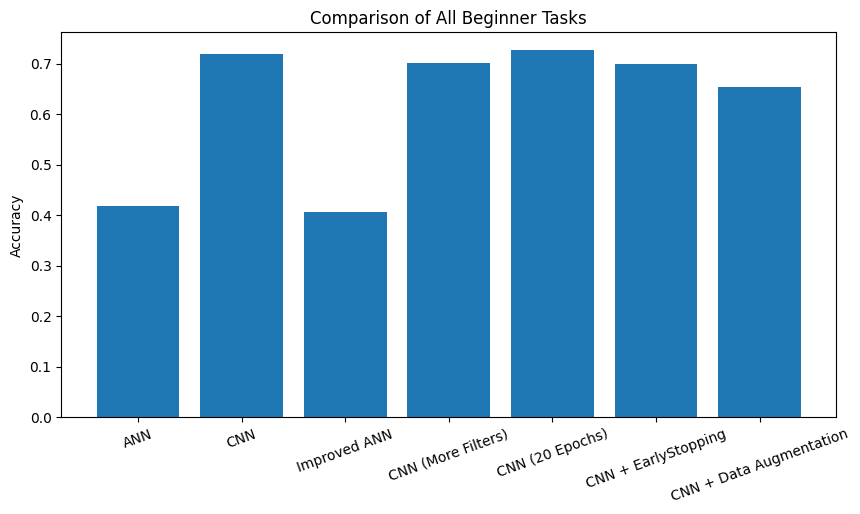

In [73]:
plt.figure(figsize=(10,5))

plt.bar(
    comparison_aug["Model"],
    comparison_aug["Test Accuracy"]
)

plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Comparison of All Beginner Tasks")

plt.show()

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**